# D009 종합 프로젝트: 동해 수온과 참다랑어류 어획량 분석

## 데이터셋 정보

### 1. 어획량 데이터
- **데이터셋 이름**: FAO Global Capture Production (한국, 참치류)
- **출처 URL**: https://www.fao.org/fishery/en/collection/capture
- **선택 이유**: 기후변화(수온 상승)로 인한 참다랑어류 북상 현상을, 국제 공식 통계로 확인하고 싶어서 선택
- **관측 단위**: 한 행 = (국가, 어종, 조업해역, 단위) 조합별 1950~2024년 연간 어획량
- **주요 컬럼 의미**:
  - `ASFIS species (Name)`: 어종명 (예: Skipjack tuna)
  - `FAO major fishing area (Name)`: 조업해역
  - 연도별 컬럼(1950~2024): 해당 연도의 어획량(톤)

### 2. 수온 데이터
- **데이터셋 이름**: 국립수산과학원 실시간 해양수산환경 관측시스템 — 동해 과거 관측정보
- **출처 URL**: https://www.nifs.go.kr/risa/risa/risaD/actionRisaPastDown.do
- **선택 이유**: 참다랑어류 어획량 변화의 배경이 되는 동해 수온 상승 추세를 실제 관측 데이터로 확인하기 위해
- **관측 단위**: 한 행 = 특정 관측소에서 30분 간격으로 측정한 표층/중층/저층 수온·염분·DO
- **주요 컬럼 의미**:
  - `관측소`: 측정 지점 (예: 강릉, 기장 등 동해안 17개소)
  - `관측일시`: 측정 시각
  - `표층수온(℃)`: 수심 약 5m 표층 수온

### ⚠️ 한계 (미리 밝힘)
FAO 데이터의 `Pacific, Northwest` 해역은 한국 근해를 포함하지만, 동해뿐 아니라 서해·일본 근해까지 포괄하는 광역 구분이다. 따라서 본 분석은 '동해 수온'과 '한국 근해 전체 어획량'의 상관관계로 해석해야 하며, 동해에 국한된 정밀한 인과관계로 확대 해석해서는 안 된다.

## 1. 인제스트(Ingest) — 수온 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# es_XXXX 하위 폴더까지 전부 뒤져서 csv 파일 찾기
files = glob.glob("data/temperature/**/*.csv", recursive=True)
print(f"총 {len(files)}개 csv 파일 발견")
print(files[:5])

총 178개 csv 파일 발견
['data/temperature\\es_2011\\동해 2011 01월.csv', 'data/temperature\\es_2011\\동해 2011 02월.csv', 'data/temperature\\es_2011\\동해 2011 03월.csv', 'data/temperature\\es_2011\\동해 2011 04월.csv', 'data/temperature\\es_2011\\동해 2011 07월.csv']


In [2]:
all_dfs = []

for f in files:
    # 파일 이름에서 연도(4자리 숫자)와 월(2자리 숫자) 추출
    match = re.search(r"(\d{4})\s*(\d{2})월", f)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
    else:
        print("연도/월을 못 찾음:", f)
        continue

    df = pd.read_csv(f, encoding="cp949")
    df["year"] = year
    df["month"] = month
    all_dfs.append(df)

temp_raw = pd.concat(all_dfs, ignore_index=True)
print("합친 전체 데이터 크기:", temp_raw.shape)
temp_raw.head()

합친 전체 데이터 크기: (3263774, 20)


,관측소,관측일시,표층수온(℃),표층 염분(psu),표층 DO(mg/L),표층수심(m),중층수온(℃),층층 염분(psu),층층 DO(mg/L),층층수심(m),저층수온(℃),저층 염분(psu),저층 DO(mg/L),저층수심(m),year,month,중충수온(℃),중충염분(psu),중충DO(mg/L),중층수심(m)
0,기장(bgj8a),2011-01-01 00:00,15.1,NaN,NaN,5.0,14.9,NaN,NaN,10.0,NaN,NaN,NaN,15.0,2011,1,NaN,NaN,NaN,NaN
1,기장(bgj8a),2011-01-01 00:30,15.0,NaN,NaN,5.0,14.7,NaN,NaN,10.0,NaN,NaN,NaN,15.0,2011,1,NaN,NaN,NaN,NaN
2,기장(bgj8a),2011-01-01 01:00,14.9,NaN,NaN,5.0,14.7,NaN,NaN,10.0,NaN,NaN,NaN,15.0,2011,1,NaN,NaN,NaN,NaN
3,기장(bgj8a),2011-01-01 01:30,14.8,NaN,NaN,5.0,14.6,NaN,NaN,10.0,NaN,NaN,NaN,15.0,2011,1,NaN,NaN,NaN,NaN
4,기장(bgj8a),2011-01-01 02:00,14.8,NaN,NaN,5.0,14.6,NaN,NaN,10.0,NaN,NaN,NaN,15.0,2011,1,NaN,NaN,NaN,NaN


## 2. 변환(Transform) — 연도별 평균 표층수온

In [3]:
yearly_temp = (
    temp_raw
    .dropna(subset=["표층수온(℃)"])
    .groupby("year")["표층수온(℃)"]
    .mean()
    .reset_index()
    .rename(columns={"표층수온(℃)": "avg_surface_temp"})
)
print(yearly_temp)

    year  avg_surface_temp
0   2011         17.140693
1   2012         15.967292
2   2013         15.708230
3   2014         16.241984
4   2015         15.327998
5   2016         16.271625
6   2017         17.075791
7   2018         16.859724
8   2019         17.084051
9   2020         16.532709
10  2021         16.536396
11  2022         16.298502
12  2023         16.978350
13  2024         17.359595
14  2025         15.738978


## 3. 인제스트 — FAO 참치 어획량 데이터 불러오기

In [4]:
tuna = pd.read_excel("data/tuna_capture/tac_KOREA_TUNA.xlsx")
print("FAO 데이터 크기:", tuna.shape)
tuna.head()

FAO 데이터 크기: (72, 154)


,Country (Name),ASFIS species (Name),FAO major fishing area (Name),Unit (Name),1950,S,1951,S.1,1952,S.2,...,2020,S.70,2021,S.71,2022,S.72,2023,S.73,2024,S.74
0,Republic of Korea,Atlantic bluefin tuna,"Atlantic, Eastern Central",Tonnes - live weight,0.0,...,0.0,...,0.0,...,...,0.00,NaN,0.00,NaN,0.00,...,0.00,...,0.00,...
1,Republic of Korea,Atlantic bluefin tuna,"Atlantic, Northeast",Tonnes - live weight,0.0,NaN,0.0,NaN,0.0,NaN,...,247.27,NaN,242.24,NaN,252.28,NaN,273.55,NaN,267.95,NaN
2,Republic of Korea,Atlantic bluefin tuna,"Atlantic, Southeast",Tonnes - live weight,0.0,...,0.0,...,0.0,...,...,0.00,NaN,0.00,NaN,0.00,...,0.00,...,0.00,...
3,Republic of Korea,Atlantic bluefin tuna,"Atlantic, Western Central",Tonnes - live weight,0.0,...,0.0,...,0.0,...,...,0.00,NaN,0.00,NaN,0.00,...,0.00,...,0.00,...
4,Republic of Korea,Atlantic bluefin tuna,Mediterranean and Black Sea,Tonnes - live weight,0.0,...,0.0,...,0.0,...,...,0.00,NaN,0.00,NaN,0.00,...,0.00,...,0.00,...


## 4. 데이터 품질 리포트 함수

In [5]:
def quality_report_full(df, name="data"):
    print(f"===== {name} 품질 리포트 =====")
    print(f"[1] 구조: {df.shape[0]}행, {df.shape[1]}열")
    print()

    print("[2] 결측치 (상위 10개)")
    missing = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(1)
    missing_df = pd.DataFrame({"결측개수": missing, "결측률(%)": missing_pct})
    print(missing_df[missing_df["결측개수"] > 0].sort_values("결측개수", ascending=False).head(10))
    print()

    print("[3] 중복행 개수:", df.duplicated().sum())
    print()

    print("[4] 컬럼별 타입 (일부)")
    print(df.dtypes.head(10))

In [6]:
quality_report_full(tuna, "FAO 참치 어획량")

===== FAO 참치 어획량 품질 리포트 =====
[1] 구조: 72행, 154열

[2] 결측치 (상위 10개)
      결측개수  결측률(%)
S.67    71    98.6
S.55    70    97.2
S.56    70    97.2
S.58    70    97.2
S.57    70    97.2
S.53    70    97.2
S.54    70    97.2
S.36    70    97.2
S.45    70    97.2
S.39    70    97.2

[3] 중복행 개수: 0

[4] 컬럼별 타입 (일부)
Country (Name)                       str
ASFIS species (Name)                 str
FAO major fishing area (Name)        str
Unit (Name)                          str
1950                             float64
S                                    str
1951                             float64
S.1                                  str
1952                             float64
S.2                                  str
dtype: object


In [7]:
quality_report_full(yearly_temp, "동해 연도별 평균수온")

===== 동해 연도별 평균수온 품질 리포트 =====
[1] 구조: 15행, 2열

[2] 결측치 (상위 10개)
Empty DataFrame
Columns: [결측개수, 결측률(%)]
Index: []

[3] 중복행 개수: 0

[4] 컬럼별 타입 (일부)
year                  int64
avg_surface_temp    float64
dtype: object


## 5. 정제(Clean) — FAO 데이터: wide → long 변환 (melt)

In [8]:
# 1단계: 필요한 컬럼만 남기고, 연도 컬럼들만 골라내기
id_cols = ["Country (Name)", "ASFIS species (Name)", "FAO major fishing area (Name)", "Unit (Name)"]

# 연도 컬럼만 골라내기 (숫자로만 된 컬럼 이름)
year_cols = [c for c in tuna.columns if str(c).isdigit()]
print(f"연도 컬럼 개수: {len(year_cols)}")
print(year_cols[:5], "...", year_cols[-5:])

연도 컬럼 개수: 75
[1950, 1951, 1952, 1953, 1954] ... [2020, 2021, 2022, 2023, 2024]


In [9]:
tuna_long = tuna.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name="year",
    value_name="catch_amount"
)

tuna_long["year"] = tuna_long["year"].astype(int)

print("melt 후 데이터 크기:", tuna_long.shape)
tuna_long.head()

melt 후 데이터 크기: (5400, 6)


,Country (Name),ASFIS species (Name),FAO major fishing area (Name),Unit (Name),year,catch_amount
0,Republic of Korea,Atlantic bluefin tuna,"Atlantic, Eastern Central",Tonnes - live weight,1950,0.0
1,Republic of Korea,Atlantic bluefin tuna,"Atlantic, Northeast",Tonnes - live weight,1950,0.0
2,Republic of Korea,Atlantic bluefin tuna,"Atlantic, Southeast",Tonnes - live weight,1950,0.0
3,Republic of Korea,Atlantic bluefin tuna,"Atlantic, Western Central",Tonnes - live weight,1950,0.0
4,Republic of Korea,Atlantic bluefin tuna,Mediterranean and Black Sea,Tonnes - live weight,1950,0.0


## 6. 정제 — 각주/합계 행 제거 (결측치 진단 및 처리)

**판단 근거**: catch_amount에 75개 결측치가 발견됐으나, 확인 결과 이는 실제 결측이 아니라 원본 엑셀의 출처 안내·합계 각주 행이 melt 과정에서 데이터 행으로 섞여 들어온 것이었다. ASFIS species(어종명) 컬럼이 비어있는 행을 기준으로 제거하였다.

In [10]:
print("catch_amount 결측치 개수:", tuna_long["catch_amount"].isna().sum())
print("catch_amount 결측치 비율: {:.1f}%".format(
    tuna_long["catch_amount"].isna().mean() * 100
))

# 결측치 있는 행 몇 개 살펴보기
tuna_long[tuna_long["catch_amount"].isna()].head()

catch_amount 결측치 개수: 75
catch_amount 결측치 비율: 1.4%


,Country (Name),ASFIS species (Name),FAO major fishing area (Name),Unit (Name),year,catch_amount
71,FAO. 2026. FishStat: Global capture production...,NaN,NaN,NaN,1950,NaN
143,FAO. 2026. FishStat: Global capture production...,NaN,NaN,NaN,1951,NaN
215,FAO. 2026. FishStat: Global capture production...,NaN,NaN,NaN,1952,NaN
287,FAO. 2026. FishStat: Global capture production...,NaN,NaN,NaN,1953,NaN
359,FAO. 2026. FishStat: Global capture production...,NaN,NaN,NaN,1954,NaN


In [11]:
# 진짜 어획량 데이터가 아닌 행(각주, 합계) 제거
# ASFIS species(어종명)가 없는 행은 진짜 데이터가 아님
before = tuna_long.shape[0]
tuna_long_clean = tuna_long.dropna(subset=["ASFIS species (Name)"])
after = tuna_long_clean.shape[0]

print(f"제거 전: {before}행 → 제거 후: {after}행 (제거된 행: {before - after}개)")

# 남은 결측치 확인
print("catch_amount 결측치:", tuna_long_clean["catch_amount"].isna().sum())

제거 전: 5400행 → 제거 후: 5175행 (제거된 행: 225개)
catch_amount 결측치: 0


In [12]:
print("어종 목록:")
print(tuna_long_clean["ASFIS species (Name)"].unique())
print()
print("조업해역 목록:")
print(tuna_long_clean["FAO major fishing area (Name)"].unique())

어종 목록:
<ArrowStringArray>
[   'Atlantic bluefin tuna',              'Bigeye tuna',
 'Frigate and bullet tunas',     'Pacific bluefin tuna',
            'Skipjack tuna',    'Southern bluefin tuna',
     'Tuna-like fishes NEI',           'Yellowfin tuna']
Length: 8, dtype: str

조업해역 목록:
<ArrowStringArray>
[  'Atlantic, Eastern Central',         'Atlantic, Northeast',
         'Atlantic, Southeast',   'Atlantic, Western Central',
 'Mediterranean and Black Sea',         'Atlantic, Northwest',
         'Atlantic, Southwest',       'Indian Ocean, Eastern',
       'Indian Ocean, Western',    'Pacific, Eastern Central',
          'Pacific, Northeast',          'Pacific, Northwest',
          'Pacific, Southeast',          'Pacific, Southwest',
    'Pacific, Western Central']
Length: 15, dtype: str


## 7. 정제 — 조업해역 한정 (한국 근해, 동해 포함 광의)

**판단 근거**: 참치는 원양성 어종으로 대부분 대서양·인도양 등 원양에서 잡히며, 동해와 직접 관련된 해역은 `Pacific, Northwest`(태평양 북서부)이다. 단, 이 해역은 동해뿐 아니라 서해·일본 근해도 포함하는 광역 구분임을 한계로 명시한다.

In [13]:
tuna_nw = tuna_long_clean[
    tuna_long_clean["FAO major fishing area (Name)"] == "Pacific, Northwest"
].copy()

print("Pacific, Northwest 데이터 크기:", tuna_nw.shape)
print()
print("어종별 데이터 개수:")
print(tuna_nw["ASFIS species (Name)"].value_counts())
tuna_nw.head()

Pacific, Northwest 데이터 크기: (375, 6)

어종별 데이터 개수:
ASFIS species (Name)
Bigeye tuna             75
Pacific bluefin tuna    75
Skipjack tuna           75
Tuna-like fishes NEI    75
Yellowfin tuna          75
Name: count, dtype: int64


,Country (Name),ASFIS species (Name),FAO major fishing area (Name),Unit (Name),year,catch_amount
15,Republic of Korea,Bigeye tuna,"Pacific, Northwest",Tonnes - live weight,1950,0.0
22,Republic of Korea,Pacific bluefin tuna,"Pacific, Northwest",Tonnes - live weight,1950,200.0
33,Republic of Korea,Skipjack tuna,"Pacific, Northwest",Tonnes - live weight,1950,0.0
51,Republic of Korea,Tuna-like fishes NEI,"Pacific, Northwest",Tonnes - live weight,1950,0.0
65,Republic of Korea,Yellowfin tuna,"Pacific, Northwest",Tonnes - live weight,1950,0.0


## 8. 변환(Transform) — 수온 데이터와 병합(merge)

In [14]:
merged = pd.merge(
    tuna_nw,
    yearly_temp,
    on="year",
    how="inner"
)

print("합친 데이터 크기:", merged.shape)
merged.head()

합친 데이터 크기: (70, 7)


,Country (Name),ASFIS species (Name),FAO major fishing area (Name),Unit (Name),year,catch_amount,avg_surface_temp
0,Republic of Korea,Bigeye tuna,"Pacific, Northwest",Tonnes - live weight,2011,0.0,17.140693
1,Republic of Korea,Pacific bluefin tuna,"Pacific, Northwest",Tonnes - live weight,2011,0.0,17.140693
2,Republic of Korea,Skipjack tuna,"Pacific, Northwest",Tonnes - live weight,2011,0.0,17.140693
3,Republic of Korea,Tuna-like fishes NEI,"Pacific, Northwest",Tonnes - live weight,2011,2002.0,17.140693
4,Republic of Korea,Yellowfin tuna,"Pacific, Northwest",Tonnes - live weight,2011,0.0,17.140693


## 9. EDA — 어종별 연도별 어획량 추이

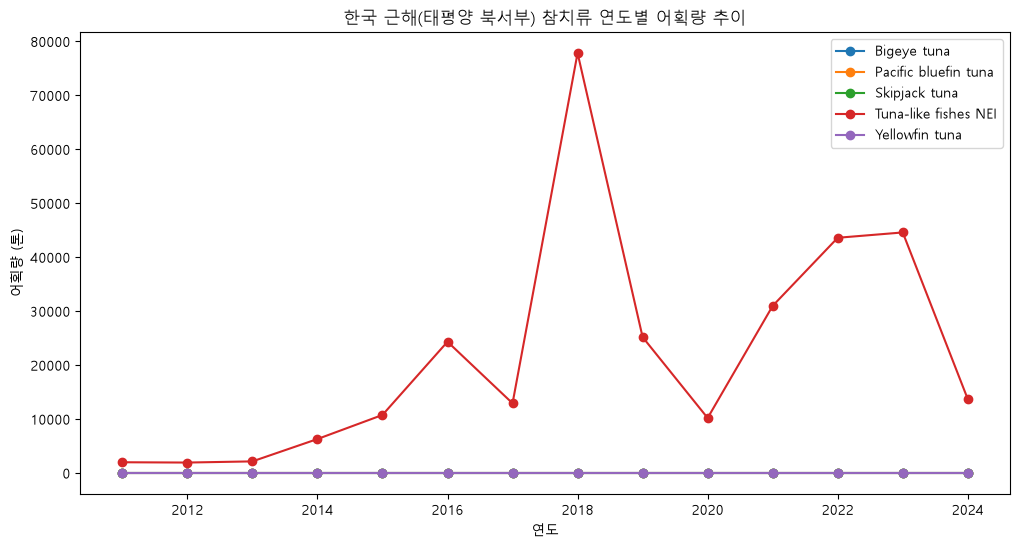

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

for species in merged["ASFIS species (Name)"].unique():
    subset = merged[merged["ASFIS species (Name)"] == species]
    ax.plot(subset["year"], subset["catch_amount"], marker="o", label=species)

ax.set_xlabel("연도")
ax.set_ylabel("어획량 (톤)")
ax.set_title("한국 근해(태평양 북서부) 참치류 연도별 어획량 추이")
ax.legend()
plt.show()

**해석**: `Tuna-like fishes NEI`(미분류 참치류)만 유의미한 어획량을 보이고, 나머지 4개 어종(Bigeye, Pacific bluefin, Skipjack, Yellowfin tuna)은 2011~2024년 전 기간 0으로 기록되어 있다. 이는 실제로 어획이 없었다기보다, 세부 어종 식별 없이 'Tuna-like fishes NEI'로 통합 보고되는 통계 관행 때문일 가능성이 높다.

## 10. EDA — 수온과 어획량의 상관관계

In [16]:
nei_only = merged[merged["ASFIS species (Name)"] == "Tuna-like fishes NEI"]
correlation = nei_only["avg_surface_temp"].corr(nei_only["catch_amount"])
print(f"수온-어획량 상관계수 (Tuna-like fishes NEI): {correlation:.3f}")

nei_only[["year", "avg_surface_temp", "catch_amount"]].sort_values("year")

수온-어획량 상관계수 (Tuna-like fishes NEI): 0.277


,year,avg_surface_temp,catch_amount
3,2011,17.140693,2002.00
8,2012,15.967292,1946.00
13,2013,15.708230,2163.00
18,2014,16.241984,6305.00
23,2015,15.327998,10767.00
28,2016,16.271625,24340.00
33,2017,17.075791,12926.00
38,2018,16.859724,77845.00
43,2019,17.084051,25196.00
48,2020,16.532709,10205.51


**해석**: 수온과 어획량 간 상관계수는 0.277로 약한 양의 상관관계를 보였다. 특히 2018년에는 상대적으로 낮은 수온에서도 최고 어획량(77,845톤)을 기록한 반면, 수온이 가장 높았던 2024년에는 오히려 어획량이 크게 감소했다. 이는 어획량이 수온 외에도 조업 노력, 어군 이동 경로, 국제 어업 규제(TAC) 등 다른 요인의 영향을 크게 받는다는 것을 시사하며, 단순 선형 상관관계로는 이 현상을 완전히 설명하기 어렵다.

## 11. 저장(Save) — Parquet 저장

In [17]:
os.makedirs("outputs", exist_ok=True)

# 1. 정제된 전체 데이터 저장
merged.to_parquet("outputs/tuna_temp_merged.parquet", index=False)
merged.to_csv("outputs/tuna_temp_merged.csv", index=False)

# 2. 어종별 KPI 요약 만들기
kpi_summary = merged.groupby("ASFIS species (Name)").agg(
    총어획량=("catch_amount", "sum"),
    평균어획량=("catch_amount", "mean"),
    최대어획량=("catch_amount", "max"),
    평균수온=("avg_surface_temp", "mean")
).reset_index()

kpi_summary.to_parquet("outputs/tuna_kpi_summary.parquet", index=False)
kpi_summary.to_csv("outputs/tuna_kpi_summary.csv", index=False)

print("저장 완료!")
print()
print(kpi_summary)

저장 완료!

   ASFIS species (Name)       총어획량         평균어획량    최대어획량       평균수온
0           Bigeye tuna       0.00      0.000000      0.0  16.527353
1  Pacific bluefin tuna       0.00      0.000000      0.0  16.527353
2         Skipjack tuna       0.00      0.000000      0.0  16.527353
3  Tuna-like fishes NEI  306588.82  21899.201429  77845.0  16.527353
4        Yellowfin tuna       0.00      0.000000      0.0  16.527353


In [18]:
# CSV vs Parquet 파일 크기 비교
csv_size = os.path.getsize("outputs/tuna_temp_merged.csv")
parquet_size = os.path.getsize("outputs/tuna_temp_merged.parquet")

print(f"CSV 파일 크기: {csv_size:,} bytes")
print(f"Parquet 파일 크기: {parquet_size:,} bytes")
print(f"Parquet이 CSV보다 약 {csv_size / parquet_size:.1f}배 작음")

CSV 파일 크기: 7,536 bytes
Parquet 파일 크기: 5,526 bytes
Parquet이 CSV보다 약 1.4배 작음


## 12. 결정 로그 (판단 근거 요약)

In [19]:
decision_log = pd.DataFrame([
    {"단계": "각주/합계 행 제거", "처리": "ASFIS species 결측 행 225개 제거", "근거": "원본 엑셀의 출처 안내·합계 각주가 melt 시 데이터 행으로 섞여 들어옴"},
    {"단계": "조업해역 한정", "처리": "Pacific, Northwest만 필터링", "근거": "동해와 가장 관련 높은 해역이나, 서해·일본 근해도 포함하는 광역 구분임을 한계로 명시"},
    {"단계": "수온 데이터 정제", "처리": "결측치(NaN) 표층수온 제거 후 연도별 평균 산출", "근거": "30분 간격 원본 데이터를 연 단위로 집계해 FAO 어획량과 결합 가능하게 함"},
    {"단계": "데이터 병합", "처리": "연도(year) 기준 inner join", "근거": "양쪽 데이터가 모두 존재하는 2011~2024년만 비교 대상으로 삼음"},
    {"단계": "저장 형식", "처리": "Parquet + CSV 동시 저장", "근거": "Parquet은 자료형 보존과 압축 효율이 높아 분석용으로, CSV는 호환성 확인용으로 병행 저장"},
])
print(decision_log.to_string(index=False))

        단계                           처리                                                     근거
각주/합계 행 제거   ASFIS species 결측 행 225개 제거              원본 엑셀의 출처 안내·합계 각주가 melt 시 데이터 행으로 섞여 들어옴
   조업해역 한정      Pacific, Northwest만 필터링       동해와 가장 관련 높은 해역이나, 서해·일본 근해도 포함하는 광역 구분임을 한계로 명시
 수온 데이터 정제 결측치(NaN) 표층수온 제거 후 연도별 평균 산출            30분 간격 원본 데이터를 연 단위로 집계해 FAO 어획량과 결합 가능하게 함
    데이터 병합       연도(year) 기준 inner join                 양쪽 데이터가 모두 존재하는 2011~2024년만 비교 대상으로 삼음
     저장 형식          Parquet + CSV 동시 저장 Parquet은 자료형 보존과 압축 효율이 높아 분석용으로, CSV는 호환성 확인용으로 병행 저장


## 13. 한계와 후속 질문

- FAO 데이터는 2024년까지만 제공되며(국제 통계 특성상 1~2년의 보고·검증 시차 존재), 2025~2026년 최신 동향은 이 데이터만으로 판단할 수 없다.
- `Pacific, Northwest` 해역은 동해뿐 아니라 서해·일본 근해까지 포괄하는 광역 구분이라, 동해에 국한된 정밀한 분석은 어렵다.
- 세부 어종(Bigeye, Pacific bluefin, Skipjack, Yellowfin tuna)의 어획량이 이 해역에서 전 기간 0으로 기록되어 있어, 실질적으로는 `Tuna-like fishes NEI`(미분류 참치류) 범주에만 의존해 분석할 수밖에 없었다.
- 수온-어획량 상관계수(0.277)는 약한 수준이며, 조업 노력·국제 어업 규제(TAC)·어군 이동 경로 등 다른 요인을 함께 고려해야 더 정확한 해석이 가능하다.
- 후속 분석에서는 국립수산과학원의 국내 어업생산동향조사(2025년 잠정치 포함)를 함께 활용하면 더 최신의 국내 동향을 보완할 수 있다.